# KNN klasifikacija nad naučenim embedinzima
- Koriste se embedinzi koje je neuronska mreža naučila u 04_triplet_embedding.ipynb
- Svaka slika je predstavljena vektorom od 128 vrednosti, tako da slike istog slova budu bliže, a slike različitih slova dalje jedna od druge
- Na tim embedinzima se trenira KNN klasifikator, koji novoj slici dodeljuje slovo na osnovu njoj najbližih slika iz trening skupa

## Pretpostavke o izlazu iz 04_triplet_embedding.ipynb

- Embedinzi su već izračunati i sačuvani na disku
- Putanja fajla: results/Triplet model/embeddings.npz
- Fajl sadrži embedinge i labele za trening, validation i test skup
- Labele su originalne oznake slova (0-8, 10-24; bez 9 i 25, jer J/Z ne postoje u skupu podataka
- Test skup nije korišćen tokom treniranja

In [1]:
import json
import sys
from pathlib import Path

import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

sys.path.insert(0, str(Path.cwd()))
from data_utils import LABEL_TO_LETTER, SEED

# Podešavanja izgleda grafika (rezolucija i veličina fonta) za sve grafike u notebook-u
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10

## Konstante

In [2]:
RESULTS_DIR = Path("../results/KNN model")
RESULTS_DIR.mkdir(exist_ok=True)

EMBEDDINGS_PATH = Path("../results/Triplet model/embeddings.npz")

# Neparne vrednosti K kako bi se izbegla jednakost u glasanju
K_VALUES = [1, 3, 5, 7, 9, 11, 15, 21, 31, 45, 61]

np.random.seed(SEED)

## Učitavanje embedinga

In [3]:
data = np.load(EMBEDDINGS_PATH)

train_embeddings, train_labels = data["train_embeddings"], data["train_labels"]
val_embeddings, val_labels = data["val_embeddings"], data["val_labels"]
test_embeddings, test_labels = data["test_embeddings"], data["test_labels"]

print(f"Train embedinzi: {train_embeddings.shape}, dtype={train_embeddings.dtype}")
print(f"Val embedinzi:   {val_embeddings.shape}")
print(f"Test embedinzi:  {test_embeddings.shape}")
print(f"Norma prvog embedinga (očekivano ~1.0): {np.linalg.norm(train_embeddings[0]):.4f}")

Train embedinzi: (23336, 128), dtype=float32
Val embedinzi:   (4119, 128)
Test embedinzi:  (7172, 128)
Norma prvog embedinga (očekivano ~1.0): 1.0000


## Biranje broja suseda K

- Isprobavaju se različite vrednosti K iz K_VALUES
- Za svaku vrednost KNN se trenira na trening embedinzima i proverava na validacionom skupu
- Kao mera sličnosti koristi se euklidsko rastojanje, isto rastojanje koje se koristi u triplet loss-u
- Bira se vrednost K koja daje najveću tačnost na validacionom skupu

In [4]:
val_accuracies = []

for k in K_VALUES:
    knn_k = KNeighborsClassifier(n_neighbors=k, metric="euclidean")
    knn_k.fit(train_embeddings, train_labels)
    val_preds = knn_k.predict(val_embeddings)
    val_acc = accuracy_score(val_labels, val_preds)
    val_accuracies.append(val_acc)
    print(f"K={k:>3d} | val_accuracy={val_acc:.4f}")

best_k = K_VALUES[int(np.argmax(val_accuracies))]
print(f"\nNajbolje K na validacionom skupu: {best_k}")

K=  1 | val_accuracy=1.0000
K=  3 | val_accuracy=1.0000
K=  5 | val_accuracy=1.0000
K=  7 | val_accuracy=1.0000
K=  9 | val_accuracy=1.0000
K= 11 | val_accuracy=1.0000
K= 15 | val_accuracy=1.0000
K= 21 | val_accuracy=1.0000
K= 31 | val_accuracy=1.0000
K= 45 | val_accuracy=1.0000
K= 61 | val_accuracy=1.0000

Najbolje K na validacionom skupu: 1


Sve isprobane vrednosti K daju maksimalnu tačnost na validacionom skupu. Ovo je očekivano jer su embedinzi dobro razdvojili različita slova (slike istog slova su uglavnom bliže jedna drugoj nego slikama drugih slova).

Zbog toga izbor K nema veliki uticaj na rezultat. Kao konačna vrednost bira se K=1, jer je tada predikcija najjednostavnija.

## Grafik tačnosti u zavisnosti od K

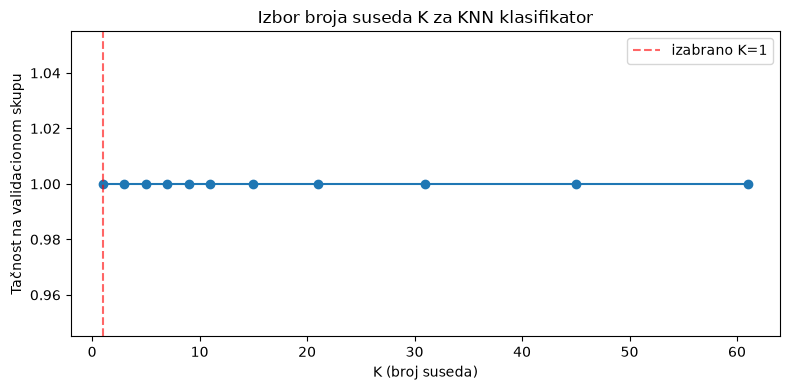

In [5]:
plt.figure(figsize=(8, 4))
plt.plot(K_VALUES, val_accuracies, marker="o")
plt.axvline(best_k, color="red", linestyle="--", alpha=0.6, label=f"izabrano K={best_k}")
plt.xlabel("K (broj suseda)")
plt.ylabel("Tačnost na validacionom skupu")
plt.title("Izbor broja suseda K za KNN klasifikator")
plt.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / "knn_k_selection.png", dpi=150)
plt.show()

## Treniranje KNN klasifikatora

- Model se trenira sa izabranim best_k, samo nad trening embedinzima kako bi poređenje sa CNN modelom bilo fer (veličina trening skupa je ista kao kod CNN modela)

In [6]:
knn = KNeighborsClassifier(n_neighbors=best_k, metric="euclidean")
knn.fit(train_embeddings, train_labels)
print(f"KNN klasifikator istreniran sa K={best_k} nad {len(train_labels)} embedinga")

KNN klasifikator istreniran sa K=1 nad 23336 embedinga


## Evaluacija na test skupu

- Test skup se koristi samo ovde, nije bio poznat ni tokom treniranja embedding mreže niti tokom biranja K

In [7]:
test_preds = knn.predict(test_embeddings)

acc = accuracy_score(test_labels, test_preds)
print(f"Tačnost na test skupu: {acc:.4f}")

Tačnost na test skupu: 1.0000


## Izveštaj po klasama (classification report)

Iste tri metrike po slovu kao i za CNN model (precision, recall, f1-score).

In [8]:
sorted_labels = sorted(LABEL_TO_LETTER.keys())
target_names = [LABEL_TO_LETTER[l] for l in sorted_labels]

report = classification_report(
    test_labels, test_preds, labels=sorted_labels,
    target_names=target_names, digits=3, zero_division=0,
)
print(report)

with open(RESULTS_DIR / "knn_classification_report.txt", "w") as f:
    f.write(f"K={best_k}\nTest accuracy: {acc:.4f}\n\n{report}")

              precision    recall  f1-score   support

           A      1.000     1.000     1.000       331
           B      1.000     1.000     1.000       432
           C      1.000     1.000     1.000       310
           D      1.000     1.000     1.000       245
           E      1.000     1.000     1.000       498
           F      1.000     1.000     1.000       247
           G      1.000     1.000     1.000       348
           H      1.000     1.000     1.000       436
           I      1.000     1.000     1.000       288
           K      1.000     1.000     1.000       331
           L      1.000     1.000     1.000       209
           M      1.000     1.000     1.000       394
           N      1.000     1.000     1.000       291
           O      1.000     1.000     1.000       246
           P      1.000     1.000     1.000       347
           Q      1.000     1.000     1.000       164
           R      1.000     1.000     1.000       144
           S      1.000    

## Matrica konfuzije

- y-osa = stvarno slovo na slici
- x-osa = slovo koje je model predvideo 

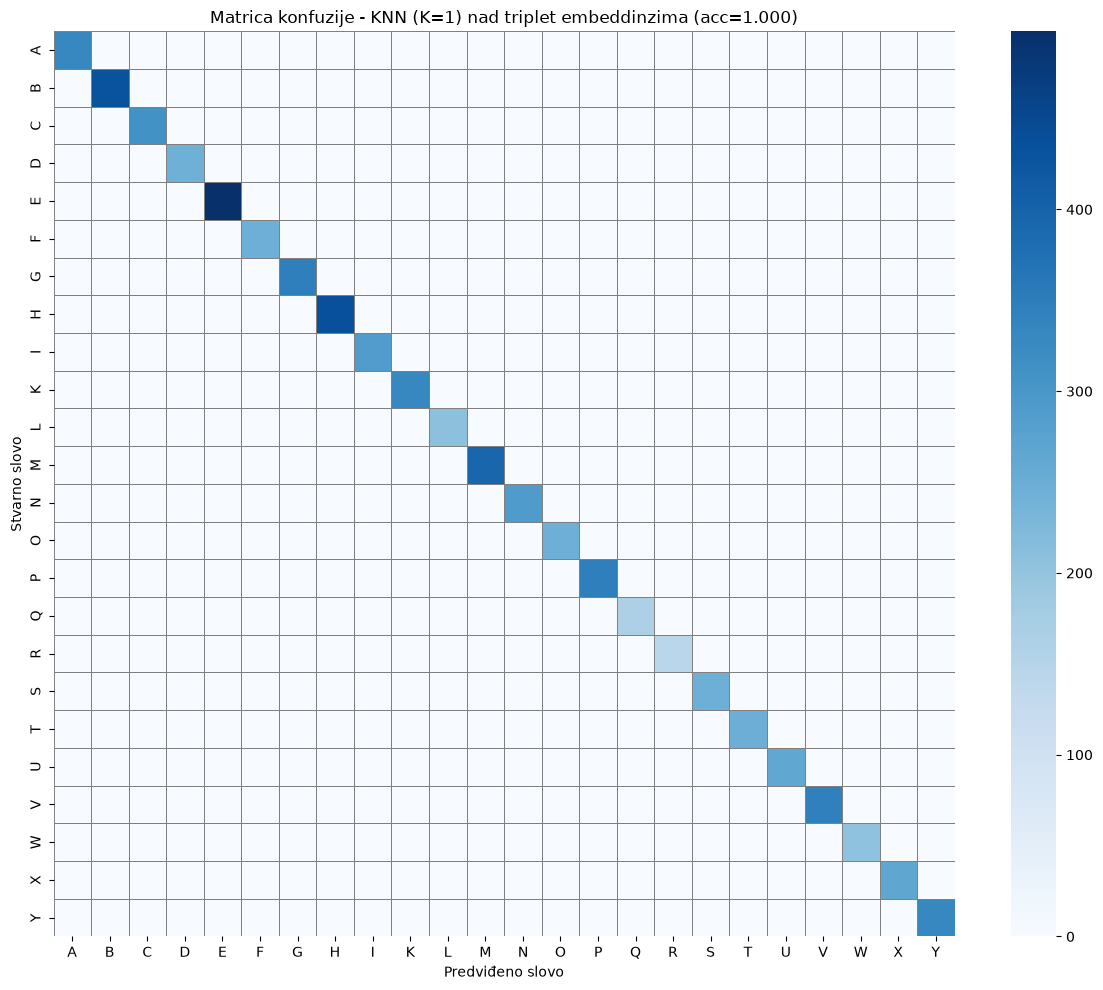

In [9]:
cm = confusion_matrix(test_labels, test_preds, labels=sorted_labels)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=False, cmap="Blues", xticklabels=target_names, yticklabels=target_names, linewidths=0.5, linecolor="gray")
plt.xlabel("Predviđeno slovo")
plt.ylabel("Stvarno slovo")
plt.title(f"Matrica konfuzije - KNN (K={best_k}) nad triplet embeddinzima (acc={acc:.3f})")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "knn_confusion_matrix.png", dpi=150)
plt.show()

## Čuvanje modela i rezultata

- knn_classifier.pkl - istrenirani KNN klasifikator
- knn_summary.json - radi poređenja sa CNN modelom

In [10]:
model_path = RESULTS_DIR / "knn_classifier.pkl"
joblib.dump(knn, model_path)
print(f"Model sačuvan: {model_path}")

macro_f1 = f1_score(test_labels, test_preds, labels=sorted_labels, average="macro")

summary = {
    "model": "knn_over_triplet_embeddings",
    "best_k": best_k,
    "metric": "euclidean",
    "embedding_dim": int(train_embeddings.shape[1]),
    "val_accuracies_by_k": dict(zip(K_VALUES, val_accuracies)),
    "test_accuracy": float(acc),
    "test_macro_f1": float(macro_f1),
    "num_train_samples": int(len(train_labels)),
    "num_val_samples": int(len(val_labels)),
    "num_test_samples": int(len(test_labels)),
}
with open(RESULTS_DIR / "knn_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

summary

Model sačuvan: ../results/KNN model/knn_classifier.pkl


{'model': 'knn_over_triplet_embeddings',
 'best_k': 1,
 'metric': 'euclidean',
 'embedding_dim': 128,
 'val_accuracies_by_k': {1: 1.0,
  3: 1.0,
  5: 1.0,
  7: 1.0,
  9: 1.0,
  11: 1.0,
  15: 1.0,
  21: 1.0,
  31: 1.0,
  45: 1.0,
  61: 1.0},
 'test_accuracy': 1.0,
 'test_macro_f1': 1.0,
 'num_train_samples': 23336,
 'num_val_samples': 4119,
 'num_test_samples': 7172}

## Kratako poređenje sa CNN modelom

- Samo tačnost na test skupu
- Detaljna analiza poređenja biće odrađena u posebnom notebook-u. Uporediti da li KNN nad embedinzima meša ista slova kao CNN (vizuelno slična slova poput M/N/S)

In [11]:
cnn_summary_path = Path("../results/CNN model/cnn_summary.json")

if cnn_summary_path.exists():
    with open(cnn_summary_path) as f:
        cnn_summary = json.load(f)
    print(f"CNN bazni model         - test accuracy: {cnn_summary['test_accuracy']:.4f}")
    print(f"KNN nad triplet embed.  - test accuracy: {acc:.4f}"
    )
else:
    print("cnn_summary.json nije pronađen - pokrenuti 03_cnn.ipynb za poređenje")

CNN bazni model         - test accuracy: 0.9997
KNN nad triplet embed.  - test accuracy: 1.0000
